# **Task H**

- Name : Vaishnavi Agarwal
- Roll No.: 230150028

In [26]:
import librosa

y, sr = librosa.load('audio.wav')
print(f"Audio loaded successfully. Signal length: {len(y)}, Sampling rate: {sr}")

Audio loaded successfully. Signal length: 103574, Sampling rate: 22050


In [27]:
n_fft_a = int(0.030 * sr)
hop_length_a = int(0.015 * sr)
n_fft_b = int(0.005 * sr)
hop_length_b = int(0.0025 * sr)
window_type = 'hanning'

print(f"Case (a): n_fft = {n_fft_a}, hop_length = {hop_length_a}")
print(f"Case (b): n_fft = {n_fft_b}, hop_length = {hop_length_b}")
print(f"Window type: {window_type}")

Case (a): n_fft = 661, hop_length = 330
Case (b): n_fft = 110, hop_length = 55
Window type: hanning


# (a) window length of 30 msec, hop length of 15 msec, window shape is hanning.

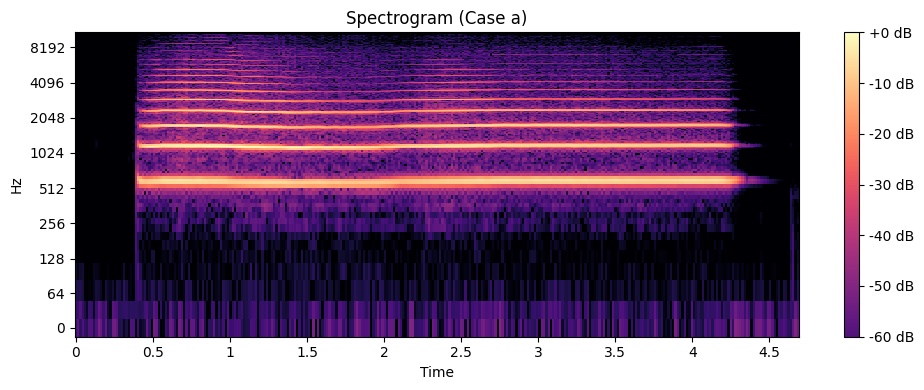

In [28]:
import matplotlib.pyplot as plt
import numpy as np
import librosa.display

stft_a = librosa.stft(y, n_fft=n_fft_a, hop_length=hop_length_a, window='hann')
spectrogram_db_a = librosa.amplitude_to_db(np.abs(stft_a), ref=np.max)

fig = plt.figure(figsize=(10, 4))
ax = fig.add_subplot(111)
img = librosa.display.specshow(spectrogram_db_a, sr=sr, hop_length=hop_length_a, x_axis='time', y_axis='log', ax=ax)
fig.colorbar(img, format='%+2.0f dB', extend='neither').ax.set_ylim([-60, 0])
ax.set_title('Spectrogram (Case a)')
plt.tight_layout()
plt.show()

# (b) window length of 5 msec, hop length of 2.5 msec, window shape is hanning

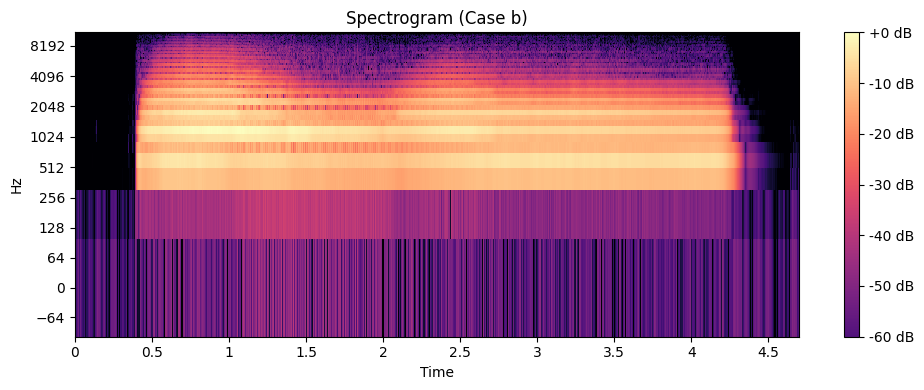

In [29]:
stft_b = librosa.stft(y, n_fft=n_fft_b, hop_length=hop_length_b, window='hann')
spectrogram_db_b = librosa.amplitude_to_db(np.abs(stft_b), ref=np.max)

fig = plt.figure(figsize=(10, 4))
ax = fig.add_subplot(111)
img_b = librosa.display.specshow(spectrogram_db_b, sr=sr, hop_length=hop_length_b, x_axis='time', y_axis='log', ax=ax)
fig.colorbar(img_b, format='%+2.0f dB', extend='neither').ax.set_ylim([-60, 0])
ax.set_title('Spectrogram (Case b)')
plt.tight_layout()
plt.show()

# (c) convolve the signal three times with itself, plot the spectrogram with settings in (1). State your observation (consider listening to the resulting signal).

In [30]:
from scipy.signal import convolve

y_convolved_1 = convolve(y, y)
y_convolved_2 = convolve(y_convolved_1, y)
y_convolved_final = convolve(y_convolved_2, y)

print(f"Length of the final convolved signal: {len(y_convolved_final)}")

Length of the final convolved signal: 414293


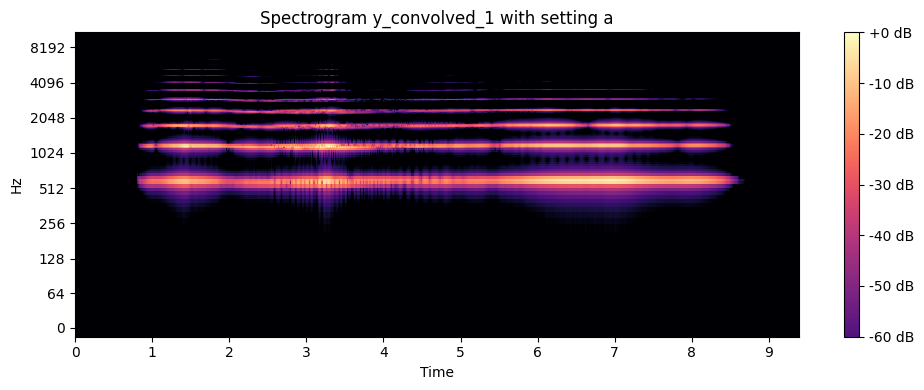

In [31]:
stft_c = librosa.stft(y_convolved_1, n_fft=n_fft_a, hop_length=hop_length_a, window='hann')
spectrogram_db_c = librosa.amplitude_to_db(np.abs(stft_c), ref=np.max)

fig = plt.figure(figsize=(10, 4))
ax = fig.add_subplot(111)
img_c = librosa.display.specshow(spectrogram_db_c, sr=sr, hop_length=hop_length_a, x_axis='time', y_axis='log', ax=ax)
fig.colorbar(img_c, format='%+2.0f dB', extend='neither').ax.set_ylim([-60, 0])
ax.set_title('Spectrogram y_convolved_1 with setting a')
plt.tight_layout()
plt.show()

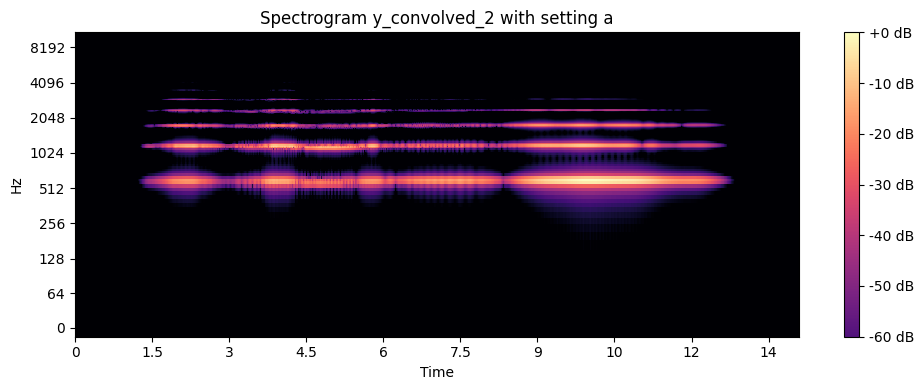

In [32]:
stft_c = librosa.stft(y_convolved_2, n_fft=n_fft_a, hop_length=hop_length_a, window='hann')
spectrogram_db_c = librosa.amplitude_to_db(np.abs(stft_c), ref=np.max)

fig = plt.figure(figsize=(10, 4))
ax = fig.add_subplot(111)
img_c = librosa.display.specshow(spectrogram_db_c, sr=sr, hop_length=hop_length_a, x_axis='time', y_axis='log', ax=ax)
fig.colorbar(img_c, format='%+2.0f dB', extend='neither').ax.set_ylim([-60, 0])
ax.set_title('Spectrogram y_convolved_2 with setting a')
plt.tight_layout()
plt.show()

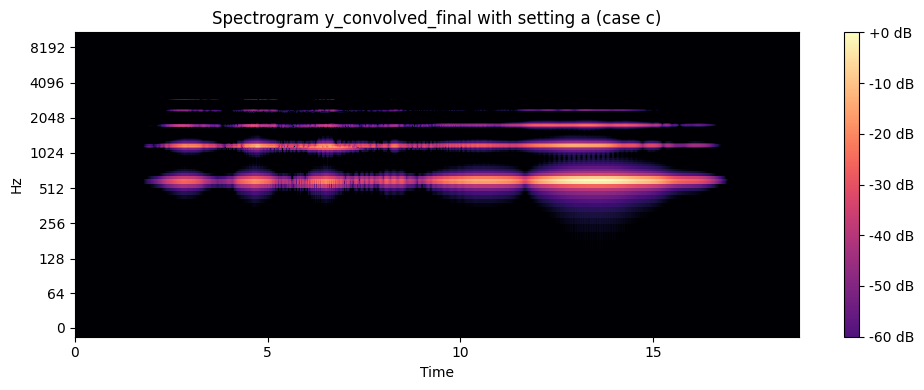

In [33]:
stft_c = librosa.stft(y_convolved_final, n_fft=n_fft_a, hop_length=hop_length_a, window='hann')
spectrogram_db_c = librosa.amplitude_to_db(np.abs(stft_c), ref=np.max)

fig = plt.figure(figsize=(10, 4))
ax = fig.add_subplot(111)
img_c = librosa.display.specshow(spectrogram_db_c, sr=sr, hop_length=hop_length_a, x_axis='time', y_axis='log', ax=ax)
fig.colorbar(img_c, format='%+2.0f dB', extend='neither').ax.set_ylim([-60, 0])
ax.set_title('Spectrogram y_convolved_final with setting a (case c)')
plt.tight_layout()
plt.show()

In [34]:
# the resultant signal

import soundfile as sf

sf.write('audio_convolved.wav', y_convolved_final, sr)


In [35]:
from IPython.display import Audio

Audio('audio_convolved.wav', rate=sr)

# Observations

### Case (a) vs. Case (b)
- **Window/Hop Lengths**:  
  - Case (a): 30 ms window, 15 ms hop  
  - Case (b): 5 ms window, 2.5 ms hop  
- **Frequency Resolution**:  
  - Case (a): better (thin horizontal lines, clearer frequency separation)  
  - Case (b): poorer (thicker bands)  
- **Time Resolution**:  
  - Case (a): lower (less detail in time axis)  
  - Case (b): higher (more detail in time axis)  
- **Usefulness**:  
  - Case (a): good for general frequency content over time  
  - Case (b): good for analyzing rapid changes  


### Case (c) vs. Case (a)
- Case (c): spectrogram of signal convolved with itself **3×**, using same parameters as Case (a)  
- **Effect of Convolution**:  
  - Time-domain convolution bi-implies frequency-domain multiplication  
  - Repeated convolution smooths the signal and spreads energy  
- **Duration**:  
  - Case (c): longer than Case (a) (convolution increases length)  
- **Frequency Content**:  
  - Case (a): sharp, distinct peaks  
  - Case (c): blurred, less distinct peaks, more spread-out energy  
- **Perceptual Effect**:  
  - Case (c): would sound more *washed-out* or *reverberant* compared to Case (a)  
